# N-Gram Analysis — Berita MBG
Analisis unigram, bigram, dan trigram dari korpus artikel berita MBG yang telah di-scrape.

## 1. Import & Load Data

In [2]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.corpus import stopwords
from collections import Counter

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/ergia/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/ergia/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /home/ergia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
df = pd.read_csv('scraped_articles.csv')
print(f'Total artikel: {len(df)}')
print(f'Artikel dengan konten: {df["content"].notna().sum()}')
df.head(2)

Total artikel: 755
Artikel dengan konten: 344


,url,title,content,error
0,https://tribratanews.polri.go.id/blog/nasional...,Wamendukbangga: Distribusi MBG untuk Ibu Hamil...,Tribratanews.polri.go.id– Jakarta. Wakil Mente...,NaN
1,https://www.tempo.co/kolom/mbg-dan-pertaruhan-...,Makan Gratis dan Pertaruhan Politik Anggaran |...,Iklan\nBerita Tempo Plus\nHandi Risza\nWakil R...,NaN


## 2. Preprocessing

In [4]:
# Gabungkan semua konten artikel menjadi satu korpus
corpus = ' '.join(df['content'].dropna().tolist())

# Lowercase
corpus = corpus.lower()

# Hapus karakter non-alfabet (angka, tanda baca, simbol)
corpus = re.sub(r'[^a-z\s]', ' ', corpus)

# Tokenisasi
tokens = word_tokenize(corpus)

print(f'Total token (sebelum hapus stopword): {len(tokens)}')

Total token (sebelum hapus stopword): 223048


In [5]:
# Hapus stopwords bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# Tambahan stopword umum yang tidak informatif
extra_stopwords = {'yang', 'di', 'dan', 'ini', 'itu', 'dari', 'ke', 'untuk',
                   'dengan', 'pada', 'dalam', 'adalah', 'akan', 'juga', 'tidak',
                   'oleh', 'atau', 'sudah', 'saat', 'bisa', 'ada', 'lebih',
                   'telah', 'serta', 'dapat', 'para', 'agar', 'hal', 'setelah'}
stop_words.update(extra_stopwords)

tokens_filtered = [t for t in tokens if t not in stop_words and len(t) > 1]

print(f'Total token (setelah hapus stopword): {len(tokens_filtered)}')

Total token (setelah hapus stopword): 141473


## 3. Generate N-Grams

In [6]:
# Unigram
unigrams = list(ngrams(tokens_filtered, 1))
unigram_freq = Counter(unigrams)

# Bigram
bigrams = list(ngrams(tokens_filtered, 2))
bigram_freq = Counter(bigrams)

# Trigram
trigrams = list(ngrams(tokens_filtered, 3))
trigram_freq = Counter(trigrams)

print(f'Jumlah unigram unik : {len(unigram_freq)}')
print(f'Jumlah bigram unik  : {len(bigram_freq)}')
print(f'Jumlah trigram unik : {len(trigram_freq)}')

Jumlah unigram unik : 11568
Jumlah bigram unik  : 61945
Jumlah trigram unik : 83790


## 4. Top N-Grams

In [7]:
TOP_N = 20

top_unigrams = unigram_freq.most_common(TOP_N)
top_bigrams  = bigram_freq.most_common(TOP_N)
top_trigrams = trigram_freq.most_common(TOP_N)

print('=== Top Unigram ===')
for gram, freq in top_unigrams:
    print(f'  {", ".join(gram):<30} {freq}')

print('\n=== Top Bigram ===')
for gram, freq in top_bigrams:
    print(f'  {", ".join(gram):<40} {freq}')

print('\n=== Top Trigram ===')
for gram, freq in top_trigrams:
    print(f'  {", ".join(gram):<55} {freq}')

=== Top Unigram ===
  program                        2616
  mbg                            2004
  gizi                           1936
  makan                          1468
  sppg                           1367
  anak                           1344
  gratis                         1168
  makanan                        1161
  bergizi                        1093
  pemerintah                     1055
  nasional                       1010
  sekolah                        933
  badan                          845
  bgn                            765
  presiden                       746
  indonesia                      735
  pangan                         624
  anggaran                       611
  masyarakat                     609
  kesehatan                      607

=== Top Bigram ===
  bergizi, gratis                          801
  makan, bergizi                           755
  gizi, nasional                           681
  program, makan                           669
  badan, gizi        

## 5. Visualisasi

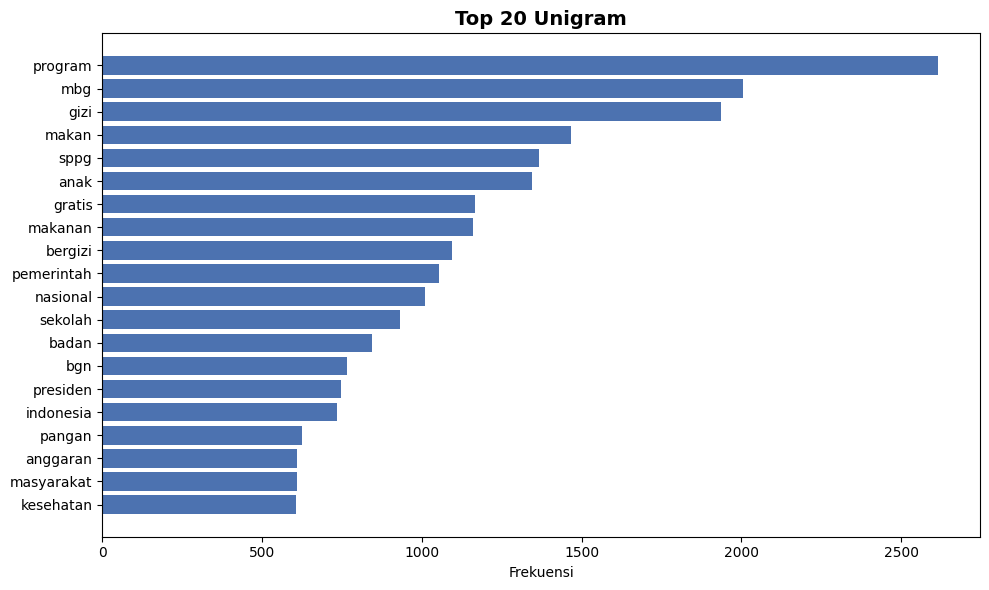

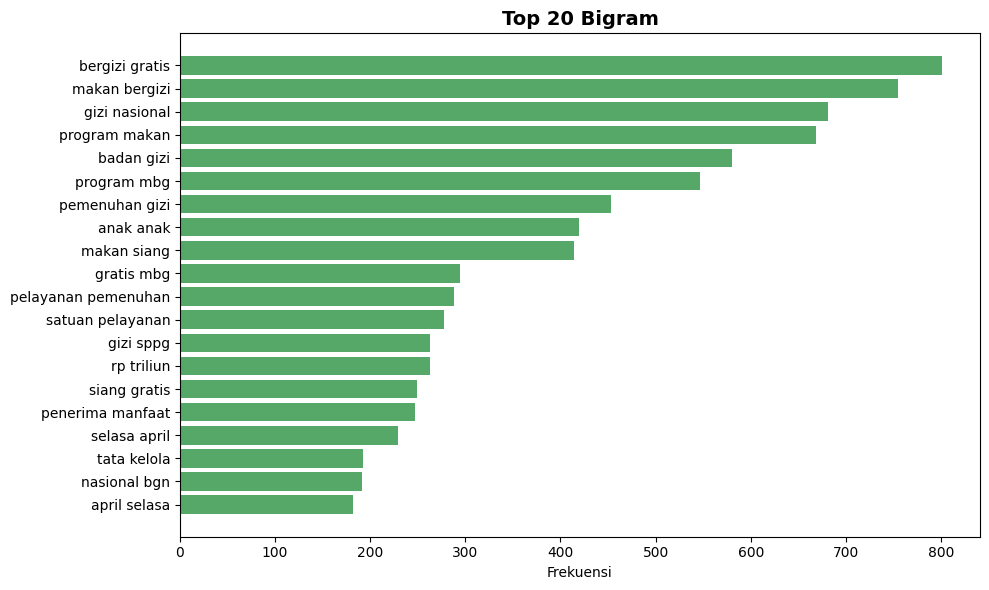

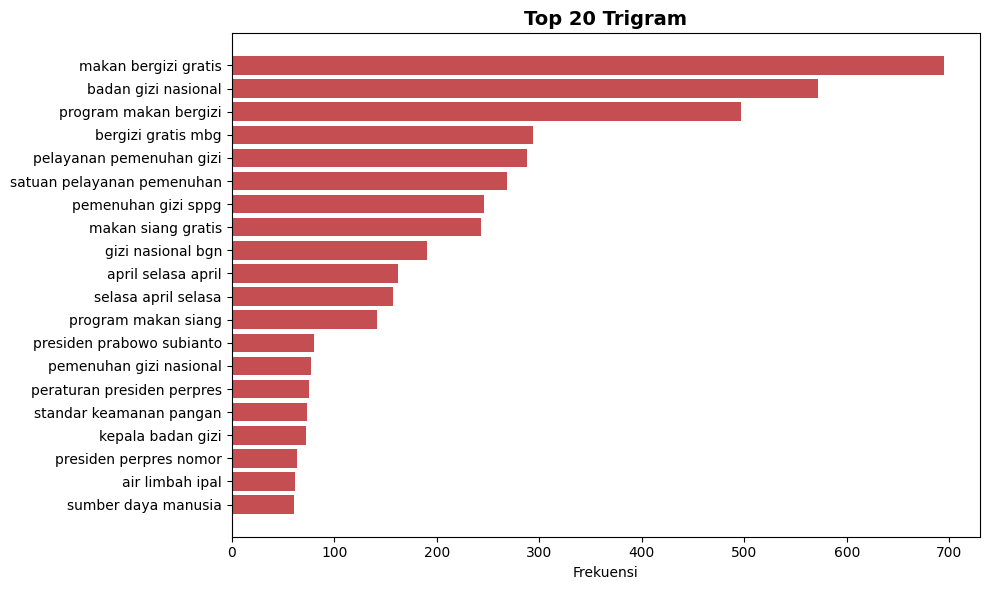

In [8]:
def plot_ngram(freq_list, title, color):
    labels = [' '.join(gram) for gram, _ in freq_list]
    values = [freq for _, freq in freq_list]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(labels[::-1], values[::-1], color=color)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    plt.tight_layout()
    plt.show()

plot_ngram(top_unigrams, f'Top {TOP_N} Unigram', '#4C72B0')
plot_ngram(top_bigrams,  f'Top {TOP_N} Bigram',  '#55A868')
plot_ngram(top_trigrams, f'Top {TOP_N} Trigram', '#C44E52')

## 6. Simpan Hasil ke CSV

In [ ]:
pd.DataFrame([((' '.join(g)), f) for g, f in unigram_freq.most_common()],
             columns=['unigram', 'frekuensi']).to_csv('ngram_unigram.csv', index=False)

pd.DataFrame([((' '.join(g)), f) for g, f in bigram_freq.most_common()],
             columns=['bigram', 'frekuensi']).to_csv('ngram_bigram.csv', index=False)

pd.DataFrame([((' '.join(g)), f) for g, f in trigram_freq.most_common()],
             columns=['trigram', 'frekuensi']).to_csv('ngram_trigram.csv', index=False)

print('Hasil disimpan ke ngram_unigram.csv, ngram_bigram.csv, ngram_trigram.csv')